In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("proton_flux_1hour.csv")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

df.head()

,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,0.035119,0.008760,0.002310,0.000122,0.000115,0.000107,0.000029,0.000004,5.482641e-07,0.000001,0.000002,8.581400e-07,2.155383e-07
1,2022-09-13 01:00:00,0.032909,0.005470,0.001240,0.000147,0.000167,0.000101,0.000025,0.000003,7.751230e-07,0.000002,0.000002,7.003604e-07,1.896722e-07
2,2022-09-13 02:00:00,0.031833,0.004444,0.000499,0.000229,0.000245,0.000124,0.000029,0.000003,7.089447e-07,0.000002,0.000002,7.965503e-07,1.982903e-07
3,2022-09-13 03:00:00,0.030375,0.002366,0.000324,0.000320,0.000265,0.000133,0.000036,0.000003,6.711190e-07,0.000002,0.000002,6.349176e-07,2.207016e-07
4,2022-09-13 04:00:00,0.024910,0.001066,0.000259,0.000328,0.000208,0.000106,0.000026,0.000004,6.711166e-07,0.000002,0.000002,6.964814e-07,2.293203e-07


In [113]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

df

Shape: (28944, 14)

Columns:
['time', '1.02_1.86_MeV', '1.9_2.3_MeV', '2.31_3.34_MeV', '3.4_6.48_MeV', '5.84_11_MeV', '11.64_23.27_MeV', '23.9_32.6_MeV', '40.7_68.2_MeV', '83.9_98.4_MeV', '99.7_118_MeV', '123_148_MeV', '156_237_MeV', '267_390_MeV']

Missing values:
time               0
1.02_1.86_MeV      0
1.9_2.3_MeV        0
2.31_3.34_MeV      0
3.4_6.48_MeV       0
5.84_11_MeV        0
11.64_23.27_MeV    0
23.9_32.6_MeV      0
40.7_68.2_MeV      0
83.9_98.4_MeV      0
99.7_118_MeV       0
123_148_MeV        0
156_237_MeV        0
267_390_MeV        0
dtype: int64

Data types:
time               datetime64[us]
1.02_1.86_MeV             float64
1.9_2.3_MeV               float64
2.31_3.34_MeV             float64
3.4_6.48_MeV              float64
5.84_11_MeV               float64
11.64_23.27_MeV           float64
23.9_32.6_MeV             float64
40.7_68.2_MeV             float64
83.9_98.4_MeV             float64
99.7_118_MeV              float64
123_148_MeV               float64
156_23

,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,0.035119,0.008760,0.002310,0.000122,0.000115,0.000107,0.000029,0.000004,5.482641e-07,0.000001,0.000002,8.581400e-07,2.155383e-07
1,2022-09-13 01:00:00,0.032909,0.005470,0.001240,0.000147,0.000167,0.000101,0.000025,0.000003,7.751230e-07,0.000002,0.000002,7.003604e-07,1.896722e-07
2,2022-09-13 02:00:00,0.031833,0.004444,0.000499,0.000229,0.000245,0.000124,0.000029,0.000003,7.089447e-07,0.000002,0.000002,7.965503e-07,1.982903e-07
3,2022-09-13 03:00:00,0.030375,0.002366,0.000324,0.000320,0.000265,0.000133,0.000036,0.000003,6.711190e-07,0.000002,0.000002,6.349176e-07,2.207016e-07
4,2022-09-13 04:00:00,0.024910,0.001066,0.000259,0.000328,0.000208,0.000106,0.000026,0.000004,6.711166e-07,0.000002,0.000002,6.964814e-07,2.293203e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28939,2025-12-31 19:00:00,0.010873,0.000025,0.000000,0.000003,0.000004,0.000009,0.000000,0.000001,5.670794e-07,0.000001,0.000001,6.925553e-07,7.758122e-08
28940,2025-12-31 20:00:00,0.011210,0.000019,0.000010,0.000005,0.000007,0.000010,0.000000,0.000001,5.670794e-07,0.000001,0.000001,6.925553e-07,5.344479e-08
28941,2025-12-31 21:00:00,0.011497,0.000019,0.000002,0.000003,0.000006,0.000010,0.000000,0.000001,5.670794e-07,0.000001,0.000001,6.925553e-07,4.999712e-08
28942,2025-12-31 22:00:00,0.009200,0.000019,0.000002,0.000005,0.000007,0.000009,0.000000,0.000001,5.670794e-07,0.000001,0.000001,6.925553e-07,7.068527e-08


In [114]:
time_diff = df["time"].diff()

print(time_diff.value_counts().head(10))

print("Minimum interval:", time_diff.min())
print("Maximum interval:", time_diff.max())

time
0 days 01:00:00    28943
Name: count, dtype: int64
Minimum interval: 0 days 01:00:00
Maximum interval: 0 days 01:00:00


In [115]:
features = df.columns[1:]

energy_df = df[["time"] + list(features)].copy()

print("Number of energy bands:", len(features))

energy_df.head()

Number of energy bands: 13


,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,0.035119,0.008760,0.002310,0.000122,0.000115,0.000107,0.000029,0.000004,5.482641e-07,0.000001,0.000002,8.581400e-07,2.155383e-07
1,2022-09-13 01:00:00,0.032909,0.005470,0.001240,0.000147,0.000167,0.000101,0.000025,0.000003,7.751230e-07,0.000002,0.000002,7.003604e-07,1.896722e-07
2,2022-09-13 02:00:00,0.031833,0.004444,0.000499,0.000229,0.000245,0.000124,0.000029,0.000003,7.089447e-07,0.000002,0.000002,7.965503e-07,1.982903e-07
3,2022-09-13 03:00:00,0.030375,0.002366,0.000324,0.000320,0.000265,0.000133,0.000036,0.000003,6.711190e-07,0.000002,0.000002,6.349176e-07,2.207016e-07
4,2022-09-13 04:00:00,0.024910,0.001066,0.000259,0.000328,0.000208,0.000106,0.000026,0.000004,6.711166e-07,0.000002,0.000002,6.964814e-07,2.293203e-07


In [116]:
energy_df[features] = energy_df[features].apply(
    pd.to_numeric,
    errors="coerce"
)

energy_df[features] = energy_df[features].interpolate(
    method="linear",
    limit_direction="both"
)

print("Missing values:")
print(energy_df[features].isnull().sum())

energy_df.head()

Missing values:
1.02_1.86_MeV      0
1.9_2.3_MeV        0
2.31_3.34_MeV      0
3.4_6.48_MeV       0
5.84_11_MeV        0
11.64_23.27_MeV    0
23.9_32.6_MeV      0
40.7_68.2_MeV      0
83.9_98.4_MeV      0
99.7_118_MeV       0
123_148_MeV        0
156_237_MeV        0
267_390_MeV        0
dtype: int64


,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,0.035119,0.008760,0.002310,0.000122,0.000115,0.000107,0.000029,0.000004,5.482641e-07,0.000001,0.000002,8.581400e-07,2.155383e-07
1,2022-09-13 01:00:00,0.032909,0.005470,0.001240,0.000147,0.000167,0.000101,0.000025,0.000003,7.751230e-07,0.000002,0.000002,7.003604e-07,1.896722e-07
2,2022-09-13 02:00:00,0.031833,0.004444,0.000499,0.000229,0.000245,0.000124,0.000029,0.000003,7.089447e-07,0.000002,0.000002,7.965503e-07,1.982903e-07
3,2022-09-13 03:00:00,0.030375,0.002366,0.000324,0.000320,0.000265,0.000133,0.000036,0.000003,6.711190e-07,0.000002,0.000002,6.349176e-07,2.207016e-07
4,2022-09-13 04:00:00,0.024910,0.001066,0.000259,0.000328,0.000208,0.000106,0.000026,0.000004,6.711166e-07,0.000002,0.000002,6.964814e-07,2.293203e-07


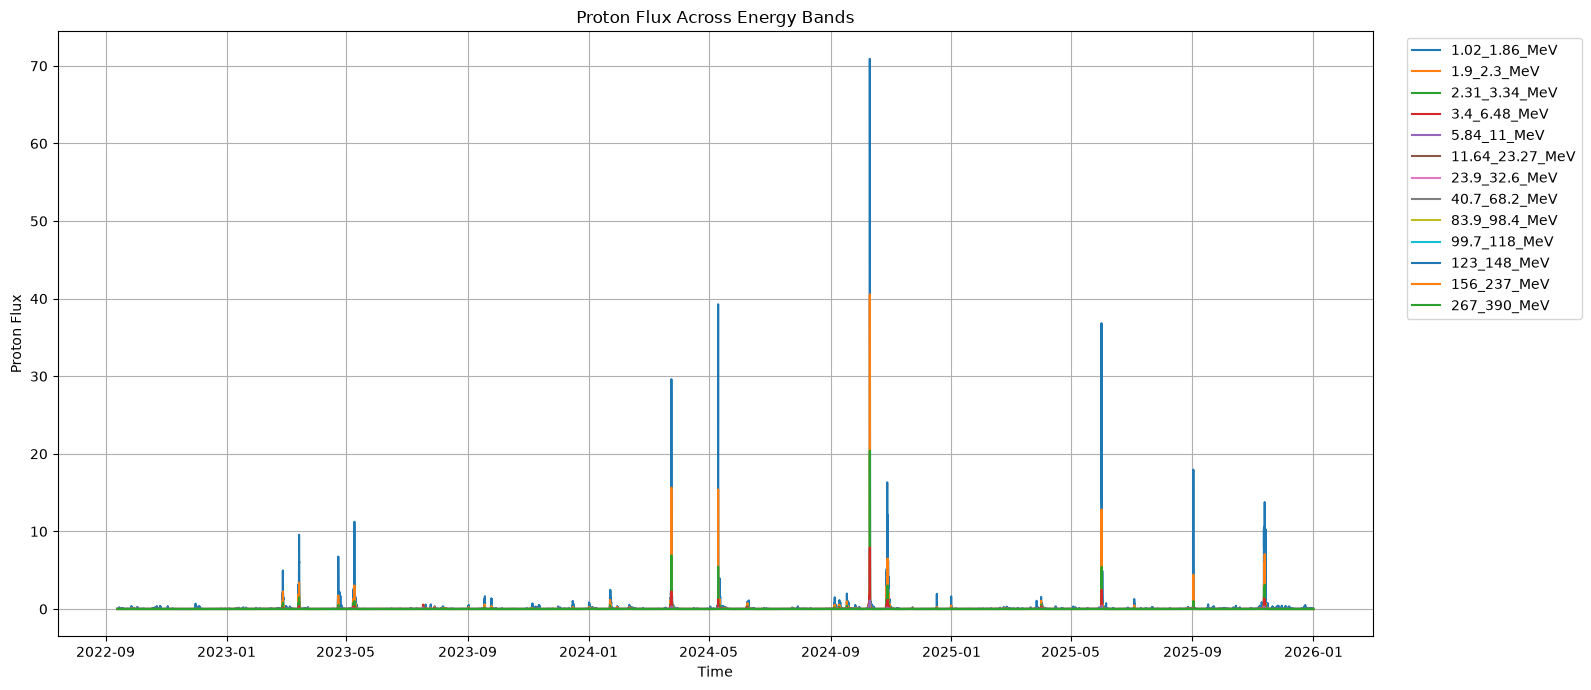

In [117]:
plt.figure(figsize=(16, 7))

for column in features:
    plt.plot(
        energy_df["time"],
        energy_df[column],
        label=column
    )

plt.xlabel("Time")
plt.ylabel("Proton Flux")
plt.title("Proton Flux Across Energy Bands")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [118]:
EPSILON = 1e-10

log_values = np.log10(
    np.maximum(
        energy_df[features].values.astype(np.float32),
        0
    ) + EPSILON
)

log_df = pd.DataFrame(
    log_values,
    columns=features
)

log_df.insert(
    0,
    "time",
    energy_df["time"].values
)

log_df.head()

,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,-1.454453,-2.057506,-2.636368,-3.913058,-3.941181,-3.971335,-4.535665,-5.410678,-6.260931,-5.878148,-5.675018,-6.066391,-6.666274
1,2022-09-13 01:00:00,-1.482688,-2.262002,-2.906423,-3.833123,-3.776272,-3.995248,-4.597546,-5.503121,-6.110573,-5.796255,-5.707376,-6.154616,-6.721767
2,2022-09-13 02:00:00,-1.497124,-2.352237,-3.302310,-3.639381,-3.610877,-3.905029,-4.540177,-5.493105,-6.149326,-5.817109,-5.677262,-6.098732,-6.702479
3,2022-09-13 03:00:00,-1.517478,-2.626048,-3.488791,-3.495493,-3.577445,-3.875035,-4.445451,-5.499194,-6.173136,-5.798538,-5.722032,-6.197214,-6.655998
4,2022-09-13 04:00:00,-1.603622,-2.972354,-3.586291,-3.483715,-3.681937,-3.974478,-4.587580,-5.426111,-6.173137,-5.817122,-5.672819,-6.157028,-6.639368


In [119]:
total_rows = len(log_df)

train_end = int(total_rows * 0.70)
validation_end = int(total_rows * 0.80)

train_df = log_df.iloc[:train_end].copy()

validation_df = log_df.iloc[
    train_end:validation_end
].copy()

test_df = log_df.iloc[
    validation_end:
].copy()

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (20260, 14)
Validation: (2895, 14)
Test: (5789, 14)


In [120]:
scaler = MinMaxScaler()

train_scaled_values = scaler.fit_transform(
    train_df[features]
)

validation_scaled_values = scaler.transform(
    validation_df[features]
)

test_scaled_values = scaler.transform(
    test_df[features]
)

train_scaled_df = pd.DataFrame(
    train_scaled_values,
    columns=features,
    index=train_df.index
)

validation_scaled_df = pd.DataFrame(
    validation_scaled_values,
    columns=features,
    index=validation_df.index
)

test_scaled_df = pd.DataFrame(
    test_scaled_values,
    columns=features,
    index=test_df.index
)

train_scaled_df.head()

,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,0.498743,0.684230,0.651100,0.558500,0.603368,0.333848,0.787180,0.419759,0.227535,0.262256,0.840016,0.508125,0.442968
1,0.494461,0.666613,0.627221,0.565834,0.619790,0.328164,0.778266,0.380085,0.325724,0.368921,0.804182,0.390076,0.417072
2,0.492272,0.658839,0.592216,0.583610,0.636261,0.349609,0.786530,0.384384,0.300417,0.341759,0.837531,0.464851,0.426073
3,0.489185,0.635251,0.575728,0.596813,0.639591,0.356739,0.800176,0.381771,0.284868,0.365948,0.787951,0.333078,0.447763
4,0.476120,0.605417,0.567106,0.597893,0.629185,0.333101,0.779701,0.413136,0.284867,0.341742,0.842451,0.386848,0.455523


In [121]:
LOOKBACK = 48
HORIZON = 48
NUM_FEATURES = len(features)

def create_sequences(data, lookback, horizon):

    X = []
    y = []

    for i in range(
        lookback,
        len(data) - horizon + 1
    ):
        X.append(
            data[i-lookback:i]
        )

        y.append(
            data[i:i+horizon]
        )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32)
    )


X_train, y_train = create_sequences(
    train_scaled_values,
    LOOKBACK,
    HORIZON
)

X_validation, y_validation = create_sequences(
    validation_scaled_values,
    LOOKBACK,
    HORIZON
)

X_test, y_test = create_sequences(
    test_scaled_values,
    LOOKBACK,
    HORIZON
)

In [122]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (20165, 48, 13)
y_train: (20165, 48, 13)
X_validation: (2800, 48, 13)
y_validation: (2800, 48, 13)
X_test: (5694, 48, 13)
y_test: (5694, 48, 13)


In [123]:
model = Sequential([

    Input(
        shape=(LOOKBACK, NUM_FEATURES)
    ),

    LSTM(
        128,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(64),

    Dropout(0.2),

    Dense(
        HORIZON * NUM_FEATURES
    ),

    Reshape(
        (HORIZON, NUM_FEATURES)
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 48, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 624)            │        40,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 48, 13)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,672 (635.44 KB)

 Trainable params: 162,672 (635.44 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0117 - mae: 0.0703 - val_loss: 0.0035 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 2/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0055 - mae: 0.0480 - val_loss: 0.0031 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 3/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0049 - mae: 0.0437 - val_loss: 0.0029 - val_mae: 0.0287 - learning_rate: 0.0010
Epoch 4/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0046 - mae: 0.0411 - val_loss: 0.0030 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 5/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0044 - mae: 0.0391 - val_loss: 0.0028 - val_mae: 0.0268 - learning_rate: 0.0010
Epoch 6/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0042 - mae: 0.0374 - val_loss: 0.0027 - val_mae: 0.0267 - learning_rate: 0.0010
Epoch 7/100
631/631 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0040 - mae: 0.0357 - val_loss: 0.0026 - val_mae: 0.0270 - learnin

In [125]:
history_df = pd.DataFrame(history.history)

history_df.head()

,loss,mae,val_loss,val_mae,learning_rate
0,0.011692,0.070322,0.003479,0.033503,0.001
1,0.005525,0.048033,0.003137,0.031783,0.001
2,0.004930,0.043662,0.002948,0.028709,0.001
3,0.004623,0.041059,0.002989,0.029765,0.001
4,0.004398,0.039082,0.002767,0.026782,0.001


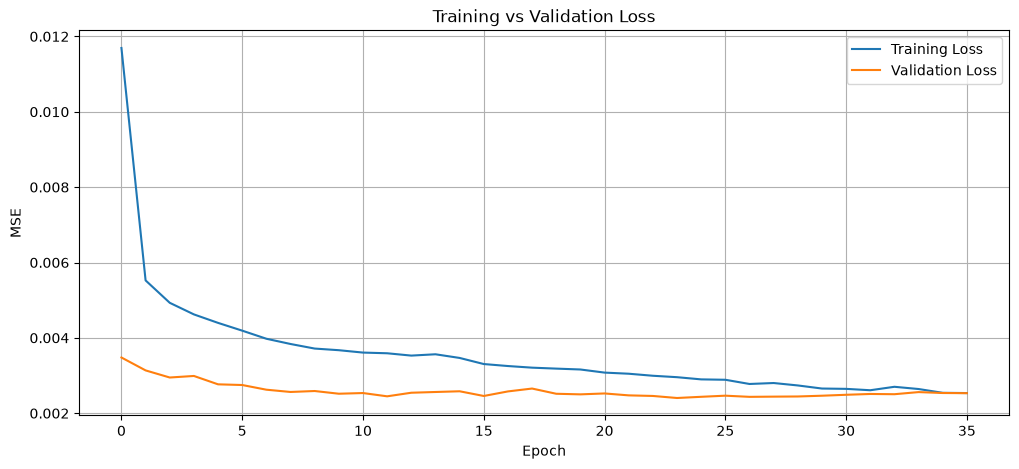

In [126]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [127]:
pred_scaled = model.predict(
    X_test,
    verbose=1
)

print("Prediction shape:", pred_scaled.shape)

178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Prediction shape: (5694, 48, 13)


In [128]:
pred_scaled_2d = pred_scaled.reshape(
    -1,
    NUM_FEATURES
)

actual_scaled_2d = y_test.reshape(
    -1,
    NUM_FEATURES
)

pred_log_2d = scaler.inverse_transform(
    pred_scaled_2d
)

actual_log_2d = scaler.inverse_transform(
    actual_scaled_2d
)

pred_log = pred_log_2d.reshape(
    -1,
    HORIZON,
    NUM_FEATURES
)

actual_log = actual_log_2d.reshape(
    -1,
    HORIZON,
    NUM_FEATURES
)

In [129]:
pred_flux = (
    np.power(10, pred_log) - EPSILON
)

actual_flux = (
    np.power(10, actual_log) - EPSILON
)

pred_flux = np.maximum(
    pred_flux,
    0
)

actual_flux = np.maximum(
    actual_flux,
    0
)

In [130]:
actual_flat = actual_flux.reshape(
    -1,
    NUM_FEATURES
)

pred_flat = pred_flux.reshape(
    -1,
    NUM_FEATURES
)

actual_df = pd.DataFrame(
    actual_flat,
    columns=features
)

pred_df = pd.DataFrame(
    pred_flat,
    columns=features
)

print("Actual DataFrame:")
display(actual_df.head())

print("Prediction DataFrame:")
display(pred_df.head())

Actual DataFrame:


,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,0.060586,0.000099,0.000374,0.000006,0.000005,0.000102,0.0,0.000001,5.670798e-07,0.000001,0.000001,6.925551e-07,6.039337e-08
1,0.073365,0.000099,0.000421,0.000012,0.000008,0.000101,0.0,0.000001,5.670798e-07,0.000001,0.000001,6.925551e-07,5.176658e-08
2,0.046560,0.000056,0.000254,0.000006,0.000009,0.000080,0.0,0.000001,5.670798e-07,0.000001,0.000001,6.925551e-07,6.557044e-08
3,0.031888,0.000069,0.000121,0.000002,0.000010,0.000058,0.0,0.000001,5.670798e-07,0.000001,0.000001,6.925551e-07,7.073429e-08
4,0.025700,0.000068,0.000111,0.000006,0.000008,0.000036,0.0,0.000001,5.670798e-07,0.000001,0.000001,6.925551e-07,5.002844e-08


Prediction DataFrame:


,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,0.179139,0.000073,0.000059,0.000022,0.000041,0.000051,7.512192e-11,0.000001,5.758326e-07,0.000002,0.000001,6.950770e-07,7.998648e-08
1,0.191122,0.000062,0.000061,0.000021,0.000042,0.000049,7.599509e-11,0.000001,5.717050e-07,0.000002,0.000001,6.933366e-07,8.012896e-08
2,0.168763,0.000065,0.000052,0.000021,0.000044,0.000047,7.516460e-11,0.000001,5.738814e-07,0.000002,0.000001,6.883955e-07,7.832602e-08
3,0.130746,0.000052,0.000049,0.000020,0.000042,0.000045,7.315985e-11,0.000001,5.749670e-07,0.000001,0.000001,6.867397e-07,7.824753e-08
4,0.088424,0.000050,0.000045,0.000020,0.000043,0.000042,6.512344e-11,0.000001,5.728796e-07,0.000001,0.000001,6.831572e-07,7.648300e-08


In [132]:
metrics = []

for i, column in enumerate(features):

    y_true = actual_flux[:, :, i].flatten()
    y_pred = pred_flux[:, :, i].flatten()

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    if np.var(y_true) > 1e-12:
        r2 = r2_score(
            y_true,
            y_pred
        )
    else:
        r2 = np.nan

    metrics.append({
        "Energy Band": column,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

metrics_df = pd.DataFrame(metrics)

display(metrics_df)

,Energy Band,MSE,RMSE,MAE,R2
0,1.02_1.86_MeV,1.089669e+00,1.043872e+00,1.197734e-01,0.018228
1,1.9_2.3_MeV,2.468595e-01,4.968496e-01,4.849052e-02,-0.164908
2,2.31_3.34_MeV,4.951331e-02,2.225159e-01,2.170080e-02,-0.088387
3,3.4_6.48_MeV,8.547637e-03,9.245343e-02,8.449838e-03,-0.194013
4,5.84_11_MeV,2.171031e-04,1.473442e-02,1.340524e-03,-0.056208
5,11.64_23.27_MeV,2.612098e-06,1.616199e-03,1.605650e-04,0.081000
6,23.9_32.6_MeV,1.385733e-22,1.177172e-11,5.817749e-12,NaN
7,40.7_68.2_MeV,9.023067e-16,3.003842e-08,1.917153e-08,NaN
8,83.9_98.4_MeV,7.594808e-17,8.714819e-09,5.313072e-09,NaN
9,99.7_118_MeV,1.249449e-16,1.117788e-08,7.697080e-09,NaN


In [133]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

display(metrics_df)

,Energy Band,MSE,RMSE,MAE,R2
0,1.02_1.86_MeV,1.089669e+00,1.043872e+00,1.197734e-01,0.018228
1,1.9_2.3_MeV,2.468595e-01,4.968496e-01,4.849052e-02,-0.164908
2,2.31_3.34_MeV,4.951331e-02,2.225159e-01,2.170080e-02,-0.088387
3,3.4_6.48_MeV,8.547637e-03,9.245343e-02,8.449838e-03,-0.194013
4,5.84_11_MeV,2.171031e-04,1.473442e-02,1.340524e-03,-0.056208
5,11.64_23.27_MeV,2.612098e-06,1.616199e-03,1.605650e-04,0.081000
6,23.9_32.6_MeV,1.385733e-22,1.177172e-11,5.817749e-12,NaN
7,40.7_68.2_MeV,9.023067e-16,3.003842e-08,1.917153e-08,NaN
8,83.9_98.4_MeV,7.594808e-17,8.714819e-09,5.313072e-09,NaN
9,99.7_118_MeV,1.249449e-16,1.117788e-08,7.697080e-09,NaN


In [134]:
print("Mean MAE:", metrics_df["MAE"].mean())
print("Median MAE:", metrics_df["MAE"].median())

print("Mean RMSE:", metrics_df["RMSE"].mean())
print("Median RMSE:", metrics_df["RMSE"].median())

print("Mean R²:", metrics_df["R2"].mean())
print("Median R²:", metrics_df["R2"].median())

Mean MAE: 0.015378133805380374
Median MAE: 6.186007084352241e-08
Mean RMSE: 0.1440032806284227
Median RMSE: 7.696192184821488e-07
Mean R²: -0.06738125284512837
Median R²: -0.07229739427566528


In [135]:
# ============================================
# PERSISTENCE BASELINE
# ============================================

persistence_predictions = []

for i in range(len(test_scaled) - LOOKBACK - HORIZON + 1):

    # Last known observation
    last_value = test_scaled[i + LOOKBACK - 1]

    # Repeat it for the next 48 hours
    future_values = np.tile(
        last_value,
        (HORIZON, 1)
    )

    persistence_predictions.append(future_values)

persistence_predictions = np.array(persistence_predictions)

print("Persistence shape:",
      persistence_predictions.shape)

Persistence shape: (5694, 48, 13)


In [136]:
# Flatten
persistence_flat = persistence_predictions.reshape(-1, len(features))

# Inverse MinMax scaling
persistence_log = scaler.inverse_transform(
    persistence_flat
)

# Convert log10 back to original flux
persistence_flux = (
    10 ** persistence_log
) - 1e-10

persistence_flux = np.clip(
    persistence_flux,
    0,
    None
)

persistence_flux = persistence_flux.reshape(
    persistence_predictions.shape
)

In [138]:

baseline_metrics = []

for i, column in enumerate(features):

    y_true = actual_flux[:, :, i].flatten()

    y_pred = persistence_flux[:, :, i].flatten()

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    if np.var(y_true) > 1e-12:
        r2 = r2_score(
            y_true,
            y_pred
        )
    else:
        r2 = np.nan

    baseline_metrics.append({
        "Energy Band": column,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

baseline_df = pd.DataFrame(
    baseline_metrics
)

display(baseline_df)

,Energy Band,MSE,RMSE,MAE,R2
0,1.02_1.86_MeV,1.820616e+00,1.349302e+00,1.779625e-01,-0.640341
1,1.9_2.3_MeV,3.499646e-01,5.915781e-01,6.616936e-02,-0.651452
2,2.31_3.34_MeV,7.387152e-02,2.717931e-01,3.055501e-02,-0.623821
3,3.4_6.48_MeV,1.177106e-02,1.084945e-01,1.144331e-02,-0.644290
4,5.84_11_MeV,3.416753e-04,1.848446e-02,1.836436e-03,-0.662253
5,11.64_23.27_MeV,4.426924e-06,2.104026e-03,2.167382e-04,-0.557501
6,23.9_32.6_MeV,0.000000e+00,0.000000e+00,0.000000e+00,NaN
7,40.7_68.2_MeV,0.000000e+00,0.000000e+00,0.000000e+00,NaN
8,83.9_98.4_MeV,0.000000e+00,0.000000e+00,0.000000e+00,NaN
9,99.7_118_MeV,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [139]:
comparison_df = metrics_df[
    ["Energy Band", "MAE", "RMSE", "R2"]
].copy()

comparison_df = comparison_df.rename(
    columns={
        "MAE": "LSTM MAE",
        "RMSE": "LSTM RMSE",
        "R2": "LSTM R2"
    }
)

comparison_df["Persistence MAE"] = baseline_df["MAE"]
comparison_df["Persistence RMSE"] = baseline_df["RMSE"]
comparison_df["Persistence R2"] = baseline_df["R2"]

display(comparison_df)

,Energy Band,LSTM MAE,LSTM RMSE,LSTM R2,Persistence MAE,Persistence RMSE,Persistence R2
0,1.02_1.86_MeV,1.197734e-01,1.043872e+00,0.018228,1.779625e-01,1.349302e+00,-0.640341
1,1.9_2.3_MeV,4.849052e-02,4.968496e-01,-0.164908,6.616936e-02,5.915781e-01,-0.651452
2,2.31_3.34_MeV,2.170080e-02,2.225159e-01,-0.088387,3.055501e-02,2.717931e-01,-0.623821
3,3.4_6.48_MeV,8.449838e-03,9.245343e-02,-0.194013,1.144331e-02,1.084945e-01,-0.644290
4,5.84_11_MeV,1.340524e-03,1.473442e-02,-0.056208,1.836436e-03,1.848446e-02,-0.662253
5,11.64_23.27_MeV,1.605650e-04,1.616199e-03,0.081000,2.167382e-04,2.104026e-03,-0.557501
6,23.9_32.6_MeV,5.817749e-12,1.177172e-11,NaN,0.000000e+00,0.000000e+00,NaN
7,40.7_68.2_MeV,1.917153e-08,3.003842e-08,NaN,0.000000e+00,0.000000e+00,NaN
8,83.9_98.4_MeV,5.313072e-09,8.714819e-09,NaN,0.000000e+00,0.000000e+00,NaN
9,99.7_118_MeV,7.697080e-09,1.117788e-08,NaN,0.000000e+00,0.000000e+00,NaN
